# Assignment 4: Build Non-Linear Models Part 2

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

The fitted curve is f(X) = 1 + X - 2(X - 1)^2I(X >= 1).  For X < 1, the indicator is zero, so the curve is the line f(X) = 1 + X.  For X >= 1, the curve becomes 1 + X - 2(X - 1)^2, which is continuous at X = 1 but bends downward after the knot.  The slope is 1 before the knot and 1 - 4(X - 1) after the knot.  The curve therefore rises linearly until X = 1, then becomes concave downward and eventually declines.

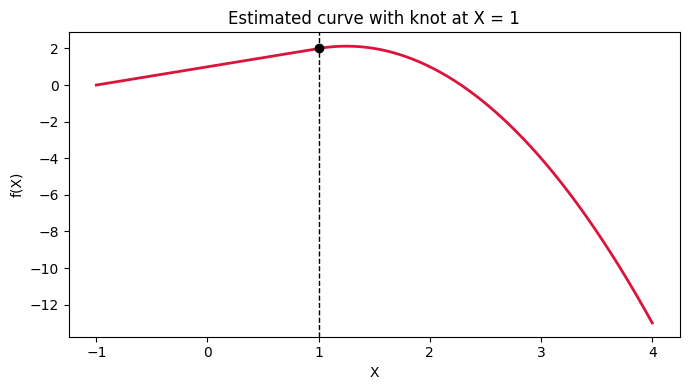

In [2]:
x = np.linspace(-1, 4, 400)
fx = 1 + x - 2 * ((x - 1) ** 2) * (x >= 1)
plt.figure(figsize=(7, 4))
plt.plot(x, fx, color="crimson", linewidth=2)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.scatter([1], [2], color="black", zorder=3)
plt.title("Estimated curve with knot at X = 1")
plt.xlabel("X")
plt.ylabel("f(X)")
plt.tight_layout()

The sketch makes the basis-function behavior visible.  The curve is continuous at the knot because both pieces equal 2 when X = 1, but the post-knot term changes the slope and creates the downward curvature requested in the question (James et al., 2023).

## Applied Question 8: Nonlinear Patterns in Auto

The Auto data set is used to test whether nonlinear functions of horsepower improve prediction of miles per gallon.  I treat this as an empirical question rather than an assumption: polynomial regression, step functions, and regression splines are compared with cross-validation and plotted so the selected shape is visible.

### Applied Question 8 Setup

Before comparing nonlinear fits, the data set is loaded once and the same 5-fold cross-validation object is reused for each method.  Keeping the split logic constant makes the polynomial, step-function, and spline comparisons easier to read because differences in RMSE come from the model form rather than from changing validation samples.

In [3]:
from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from patsy import dmatrix

auto = load_data("Auto").dropna()
X_hp = auto[["horsepower"]]
y = auto["mpg"]
hp_grid = pd.DataFrame({"horsepower": np.linspace(auto["horsepower"].min(), auto["horsepower"].max(), 250)})
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

display(auto[["horsepower", "mpg"]].isna().sum().rename("missing_count").to_frame())
display(auto[["horsepower", "mpg"]].describe().T)

,missing_count
horsepower,0
mpg,0


,count,mean,std,min,25%,50%,75%,max
horsepower,392.0,104.469388,38.491160,46.0,75.0,93.50,126.0,230.0
mpg,392.0,23.445918,7.805007,9.0,17.0,22.75,29.0,46.6


The setup table shows that horsepower and mpg have no remaining missing values after the standard Auto cleanup.  The summary statistics also show why a nonlinear check is reasonable: horsepower has a wide range, and mpg is a performance outcome that plausibly changes rapidly at lower horsepower and then flattens among higher-horsepower cars.

### Part (a): Polynomial Regression CV Table

The first comparison fits polynomial regressions from degree 1 through degree 10.  Cross-validation is used because the question is not whether a higher-degree polynomial can reduce training error, but whether the added curvature improves held-out prediction.

In [4]:
poly_rows = []
poly_models = {}
for degree in range(1, 11):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("lm", LinearRegression()),
    ])
    rmse = (-cross_val_score(model, X_hp, y, cv=kf, scoring="neg_root_mean_squared_error")).mean()
    model.fit(X_hp, y)
    poly_models[degree] = model
    poly_rows.append({"degree": degree, "cv_rmse": rmse})

poly_cv = pd.DataFrame(poly_rows)
poly_cv_ranked = poly_cv.assign(delta_from_best=lambda df: df["cv_rmse"] - df["cv_rmse"].min()).sort_values("cv_rmse")
best_poly_degree = int(poly_cv.loc[poly_cv["cv_rmse"].idxmin(), "degree"])
display(poly_cv_ranked)
print(f"Best polynomial degree by 5-fold CV: {best_poly_degree}")

,degree,cv_rmse,delta_from_best
6,7,4.320763,0.000000
5,6,4.330575,0.009813
4,5,4.336834,0.016072
7,8,4.349046,0.028283
1,2,4.363577,0.042815
2,3,4.365086,0.044323
3,4,4.383383,0.062620
8,9,4.386715,0.065953
9,10,4.433756,0.112994
0,1,4.909374,0.588612


Best polynomial degree by 5-fold CV: 7


The polynomial CV table identifies the numerically best degree, but it also shows whether that best value is meaningfully separated from simpler alternatives.  When the top few RMSE values are close, the lower-degree model deserves serious consideration because it is easier to explain and less likely to create boundary wiggle.  This is why the table includes `delta_from_best` instead of only reporting the winning degree.

### Part (a): Polynomial Coefficients

The selected polynomial is fit on the full Auto data set so its coefficient estimates can be inspected.  The coefficients are reported after the polynomial features are standardized inside the pipeline, so the table is most useful for confirming the fitted form rather than for interpreting raw horsepower units.

In [5]:
best_poly = poly_models[best_poly_degree]
poly_feature_names = best_poly.named_steps["poly"].get_feature_names_out(["horsepower"])
poly_coef = pd.DataFrame({
    "term": ["intercept"] + list(poly_feature_names),
    "coefficient": [best_poly.named_steps["lm"].intercept_] + list(best_poly.named_steps["lm"].coef_),
})
display(poly_coef)

,term,coefficient
0,intercept,23.445918
1,horsepower,1278.303227
2,horsepower^2,-8307.469287
3,horsepower^3,23801.509523
4,horsepower^4,-38293.766453
5,horsepower^5,35985.872749
6,horsepower^6,-18471.924855
7,horsepower^7,4002.865375


The coefficient table confirms that the selected polynomial uses several transformed horsepower terms.  That flexibility helps capture curvature, but it also makes the model harder to read directly.  For this reason, the fitted curve plot later in the section is more informative than trying to interpret each high-order coefficient by itself.

### Part (b): Step-Function CV Table

The step-function approach converts horsepower into bins and estimates a separate mean structure across those intervals.  This is easy to explain, but it forces the fitted relationship to jump at cut points even when the real relationship is smooth.

In [6]:
step_rows = []
step_predictions = {}
for bins in range(2, 8):
    quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, bins + 1)))
    rmses = []
    for train_idx, test_idx in kf.split(auto):
        train_df = auto.iloc[train_idx].copy()
        test_df = auto.iloc[test_idx].copy()
        train_design = pd.get_dummies(pd.cut(train_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = pd.get_dummies(pd.cut(test_df["horsepower"], bins=quantiles, include_lowest=True), drop_first=True)
        test_design = test_design.reindex(columns=train_design.columns, fill_value=0)
        lm = LinearRegression().fit(train_design, train_df["mpg"])
        rmses.append(np.sqrt(mean_squared_error(test_df["mpg"], lm.predict(test_design))))
    step_rows.append({"bins": bins, "cv_rmse": np.mean(rmses)})

step_cv = pd.DataFrame(step_rows).assign(delta_from_best=lambda df: df["cv_rmse"] - df["cv_rmse"].min()).sort_values("cv_rmse")
best_bins = int(step_cv.loc[step_cv["cv_rmse"].idxmin(), "bins"])
best_quantiles = np.unique(np.quantile(auto["horsepower"], np.linspace(0, 1, best_bins + 1)))
step_design = pd.get_dummies(pd.cut(auto["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
step_model = LinearRegression().fit(step_design, y)
grid_step_design = pd.get_dummies(pd.cut(hp_grid["horsepower"], bins=best_quantiles, include_lowest=True), drop_first=True)
grid_step_design = grid_step_design.reindex(columns=step_design.columns, fill_value=0)
step_predictions["best"] = step_model.predict(grid_step_design)

display(step_cv)
print(f"Best step-function bin count by 5-fold CV: {best_bins}")

,bins,cv_rmse,delta_from_best
4,6,4.345419,0.000000
5,7,4.441480,0.096062
2,4,4.485108,0.139690
3,5,4.581382,0.235964
1,3,4.823162,0.477743
0,2,5.451271,1.105852


Best step-function bin count by 5-fold CV: 6


The step-function table shows the trade-off between readability and smoothness.  More bins allow the fitted values to adapt to local changes in horsepower, but too many bins can make the result depend heavily on where the cut points land.  If the selected bin count is only slightly better than a nearby alternative, the practical interpretation should emphasize the general downward pattern rather than a specific threshold.

### Part (c): Cubic Spline CV Table

The cubic spline comparison uses degrees of freedom from 3 through 8.  Splines are useful here because they allow local bending while avoiding the global behavior of high-degree polynomials.

In [7]:
spline_rows = []
spline_models = {}
for df in range(3, 9):
    basis = dmatrix(f"bs(horsepower, df={df}, degree=3, include_intercept=False)", auto, return_type="dataframe")
    rmses = []
    for train_idx, test_idx in kf.split(basis):
        lm = LinearRegression().fit(basis.iloc[train_idx], y.iloc[train_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[test_idx], lm.predict(basis.iloc[test_idx]))))
    lm_full = LinearRegression().fit(basis, y)
    spline_models[df] = (lm_full, basis.design_info)
    spline_rows.append({"spline_df": df, "cv_rmse": np.mean(rmses)})

spline_cv = pd.DataFrame(spline_rows).assign(delta_from_best=lambda df: df["cv_rmse"] - df["cv_rmse"].min()).sort_values("cv_rmse")
best_spline_df = int(spline_cv.loc[spline_cv["cv_rmse"].idxmin(), "spline_df"])
best_spline_model, best_spline_design = spline_models[best_spline_df]
grid_basis = dmatrix(best_spline_design, hp_grid, return_type="dataframe")

display(spline_cv)
print(f"Best cubic spline df by 5-fold CV: {best_spline_df}")

,spline_df,cv_rmse,delta_from_best
2,5,4.304730,0.000000
3,6,4.349019,0.044289
1,4,4.351553,0.046823
0,3,4.365086,0.060356
5,8,4.382779,0.078049
4,7,4.385691,0.080961


Best cubic spline df by 5-fold CV: 5


The spline table is the most useful comparison for balancing fit and shape.  A small number of degrees of freedom may underfit the bend in the horsepower-mpg relationship, while too many degrees of freedom can chase sample noise.  The selected spline gives a flexible but still controlled nonlinear fit, which is the main reason splines are often preferable to high-degree global polynomials (Hastie & Tibshirani, 1990; James et al., 2023).

### Applied Question 8 Fitted-Curve Comparison

The final figure puts the selected polynomial, step-function, and spline fits on the same visual scale.  This is the point where the cross-validation tables become interpretable as fitted relationships rather than only as RMSE rankings.

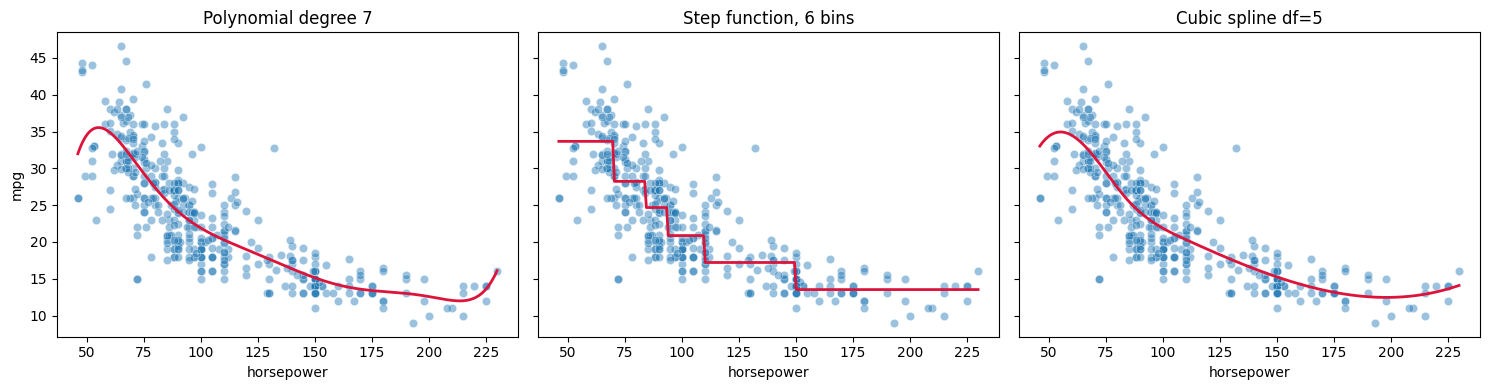

In [8]:
hp_grid["polynomial_fit"] = best_poly.predict(hp_grid)
hp_grid["step_fit"] = step_predictions["best"]
hp_grid["spline_fit"] = best_spline_model.predict(grid_basis)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col, title in [
    (axes[0], "polynomial_fit", f"Polynomial degree {best_poly_degree}"),
    (axes[1], "step_fit", f"Step function, {best_bins} bins"),
    (axes[2], "spline_fit", f"Cubic spline df={best_spline_df}"),
]:
    sns.scatterplot(data=auto, x="horsepower", y="mpg", alpha=.45, ax=ax)
    ax.plot(hp_grid["horsepower"], hp_grid[col], color="crimson", linewidth=2)
    ax.set_title(title)
plt.tight_layout()

The figure shows the same substantive story across the three methods: mpg drops as horsepower increases, with the steepest decline occurring before the relationship starts to flatten.  The step function communicates the broad levels clearly but introduces artificial jumps.  The polynomial and spline fits are smoother, but the spline is easier to defend because its flexibility is local rather than controlled by one high-degree global curve.  Overall, Applied Question 8 supports the use of nonlinear terms for horsepower, with the spline fit offering the best balance between predictive flexibility and interpretability.

## Kaggle Nonlinear Models

The Abalone competition work extends the nonlinear modeling theme from Auto using Chapter 7-style feature transformations.  A shared data preparation step holds missingness checks, physical-value cleaning, preprocessing, and the validation split constant.  The two fresh submissions are polynomial ridge regression and spline ridge regression, so the leaderboard evidence is tied directly to nonlinear basis expansions rather than to tree ensembles.

### Kaggle Shared Setup: Raw Data Quality

Both Kaggle models use the same training data, test data, validation split, and preprocessing logic.  The first check is a raw data-quality table so the modeling section does not assume the competition files are already clean.

In [9]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, SplineTransformer, StandardScaler

abalone_raw = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
abalone_test_raw = pd.read_csv(KAGGLE / "playground-series-s4e4" / "test.csv")
expected_columns = {"id", "Sex", "Length", "Diameter", "Height", "Whole weight", "Whole weight.1", "Whole weight.2", "Shell weight", "Rings"}
expected_test_columns = expected_columns - {"Rings"}
missing_expected = sorted(expected_columns - set(abalone_raw.columns))
missing_expected_test = sorted(expected_test_columns - set(abalone_test_raw.columns))
duplicate_ids = int(abalone_raw["id"].duplicated().sum()) if "id" in abalone_raw else 0
duplicate_test_ids = int(abalone_test_raw["id"].duplicated().sum()) if "id" in abalone_test_raw else 0
missing_by_column = abalone_raw.isna().sum()
missing_by_column_test = abalone_test_raw.isna().sum()
numeric_cols_raw = abalone_raw.select_dtypes(include=np.number).columns.tolist()
physical_cols = [c for c in numeric_cols_raw if c not in ["id", "Rings"]]
nonpositive_physical = {c: int((abalone_raw[c] <= 0).sum()) for c in physical_cols}
nonpositive_physical_test = {c: int((abalone_test_raw[c] <= 0).sum()) for c in physical_cols if c in abalone_test_raw.columns}

quality_table = pd.DataFrame({
    "quality_check": [
        "train_rows",
        "test_rows",
        "missing_expected_train_columns",
        "missing_expected_test_columns",
        "duplicate_train_ids",
        "duplicate_test_ids",
        "train_total_missing_values",
        "test_total_missing_values",
        "train_nonpositive_physical_values",
        "test_nonpositive_physical_values",
    ],
    "value": [
        len(abalone_raw),
        len(abalone_test_raw),
        missing_expected,
        missing_expected_test,
        duplicate_ids,
        duplicate_test_ids,
        int(missing_by_column.sum()),
        int(missing_by_column_test.sum()),
        nonpositive_physical,
        nonpositive_physical_test,
    ],
})
display(quality_table)

,quality_check,value
0,train_rows,90615
1,test_rows,60411
2,missing_expected_train_columns,[]
3,missing_expected_test_columns,[]
4,duplicate_train_ids,0
5,duplicate_test_ids,0
6,train_total_missing_values,0
7,test_total_missing_values,0
8,train_nonpositive_physical_values,"{'Length': 0, 'Diameter': 0, 'Height': 6, 'Who..."
9,test_nonpositive_physical_values,"{'Length': 0, 'Diameter': 0, 'Height': 2, 'Who..."


The quality table shows that the expected columns are present and that the train/test row counts line up with the competition files.  The important finding is not ordinary missingness, but nonpositive physical measurements.  Those values are not biologically meaningful for measurements such as Height, so the cleaning step should flag them instead of passing them directly into nonlinear transformations.

### Kaggle Shared Setup: Cleaning Flags

The cleaning rule is intentionally conservative.  Duplicate training IDs would be removed, missing targets would be dropped, and nonpositive physical measurements are converted to missing values so they can be imputed inside the modeling pipeline.

In [10]:
if missing_expected:
    raise ValueError(f"Missing expected Abalone columns: {missing_expected}")
if missing_expected_test:
    raise ValueError(f"Missing expected Abalone test columns: {missing_expected_test}")

def clean_abalone_frame(frame, *, has_target):
    cleaned = frame.copy()
    if has_target and cleaned["id"].duplicated().any():
        cleaned = cleaned.drop_duplicates(subset=["id"], keep="first")
    if has_target and cleaned["Rings"].isna().any():
        cleaned = cleaned.dropna(subset=["Rings"])
    for col in physical_cols:
        if col in cleaned.columns:
            cleaned.loc[cleaned[col] <= 0, col] = np.nan
    return cleaned

abalone = clean_abalone_frame(abalone_raw, has_target=True)
abalone_test = clean_abalone_frame(abalone_test_raw, has_target=False)
if duplicate_ids:
    print(f"Dropped {duplicate_ids} duplicate training ids before modeling.")
display(abalone.isna().sum().rename("train_missing_after_cleaning_flags").to_frame().query("train_missing_after_cleaning_flags > 0"))
display(abalone_test.isna().sum().rename("test_missing_after_cleaning_flags").to_frame().query("test_missing_after_cleaning_flags > 0"))

,train_missing_after_cleaning_flags
Height,6


,test_missing_after_cleaning_flags
Height,2


The cleaning output makes the Height issue explicit.  These values are converted to missing rather than removed because the records still contain useful information in the other shell and weight measurements.  Median imputation is then fit inside each model pipeline, which avoids leaking validation information into the training transformations (Little & Rubin, 2019).

### Kaggle Shared Setup: Split, Baseline, and Helpers

The final setup cell creates the train/validation split, the full training matrix for final test-set predictions, and a mean baseline.  The baseline matters because the two submitted nonlinear models should improve on a simple average-ring prediction before their leaderboard scores are treated as meaningful.

In [11]:
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
numeric_predictors = [c for c in X.columns if c not in ["id", "Sex"]]
X_train, X_valid, y_train, y_valid = train_test_split(X.drop(columns=["id"]), y, test_size=.2, random_state=RANDOM_STATE)
X_full = X.drop(columns=["id"])
X_test = abalone_test.drop(columns=["id"])
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
baseline_rmsle = np.sqrt(mean_squared_log_error(y_valid, baseline_pred))
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "mean_baseline_rmsle", "target_min", "target_max"],
    "value": [len(X_train), len(X_valid), baseline_rmsle, y.min(), y.max()],
}))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.maximum(y_pred, 1)))

def coefficient_table(model, top_n=12):
    coef = model.named_steps["model"].coef_
    try:
        names = model.named_steps["pre"].get_feature_names_out()
    except Exception:
        names = [f"x{i}" for i in range(len(coef))]
    return (
        pd.DataFrame({"feature": names, "coefficient": coef, "abs_coefficient": np.abs(coef)})
        .sort_values("abs_coefficient", ascending=False)
        .head(top_n)
        .drop(columns="abs_coefficient")
    )

def residual_summary(name, y_true, y_pred):
    residuals = y_true - np.maximum(y_pred, 1)
    return {
        "model": name,
        "validation_rmsle": rmsle(y_true, y_pred),
        "mean_residual": residuals.mean(),
        "median_abs_residual": np.median(np.abs(residuals)),
        "residual_skew": pd.Series(residuals).skew(),
        "corr_abs_residual_pred": np.corrcoef(np.abs(residuals), np.maximum(y_pred, 1))[0, 1],
    }

def error_by_prediction_range(name, y_true, y_pred):
    frame = pd.DataFrame({"actual": y_true.to_numpy(), "predicted": np.maximum(y_pred, 1)})
    frame["abs_residual"] = np.abs(frame["actual"] - frame["predicted"])
    frame["prediction_band"] = pd.qcut(frame["predicted"], q=4, duplicates="drop")
    return (
        frame.groupby("prediction_band", observed=True)
        .agg(model=("predicted", lambda s: name), n=("actual", "size"), mean_prediction=("predicted", "mean"), mean_abs_residual=("abs_residual", "mean"))
        .reset_index()
    )

ridge_alpha_grid = [0.1, 1, 5, 10, 25, 50, 100]

,setup_check,value
0,training_rows,72492.000000
1,validation_rows,18123.000000
2,mean_baseline_rmsle,0.290949
3,target_min,1.000000
4,target_max,29.000000


The baseline table sets the standard for the Kaggle models.  A nonlinear model that cannot beat the mean baseline on validation RMSLE would not justify the added basis expansion.  The helper functions are defined here so the later model cells stay focused on one model result at a time.

### Kaggle Model 1: Polynomial Ridge

The first fresh Kaggle model uses second-degree polynomial basis functions for the numeric Abalone measurements, then applies ridge regression to stabilize the expanded design matrix.  This keeps the model aligned with the Week 4 nonlinearity methods while still recognizing that length, diameter, height, and weight variables are highly related.

In [12]:
poly_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
])
poly_pre = ColumnTransformer([
    ("cat", cat_pipe, ["Sex"]),
    ("poly_num", poly_num_pipe, numeric_predictors),
])
poly_alpha_rows = []
for alpha in ridge_alpha_grid:
    candidate = Pipeline([
        ("pre", clone(poly_pre)),
        ("model", Ridge(alpha=alpha)),
    ])
    candidate.fit(X_train, y_train)
    poly_alpha_rows.append({
        "alpha": alpha,
        "validation_rmsle": rmsle(y_valid, candidate.predict(X_valid)),
    })
poly_alpha_table = pd.DataFrame(poly_alpha_rows).sort_values("validation_rmsle")
display(poly_alpha_table)
poly_alpha = float(poly_alpha_table.iloc[0]["alpha"])
poly_ridge_model = Pipeline([
    ("pre", clone(poly_pre)),
    ("model", Ridge(alpha=poly_alpha)),
])
poly_ridge_model.fit(X_train, y_train)
poly_valid_pred = poly_ridge_model.predict(X_valid)
poly_ridge_rmsle = rmsle(y_valid, poly_valid_pred)
poly_ridge_full = Pipeline([
    ("pre", clone(poly_pre)),
    ("model", Ridge(alpha=poly_alpha)),
])
poly_ridge_full.fit(X_full, y)
poly_test_pred = np.maximum(poly_ridge_full.predict(X_test), 1)
poly_submission_file = "A4_polynomial_ridge_chapter7_playground_series_s4e4.csv"
pd.DataFrame({"id": abalone_test["id"], "Rings": poly_test_pred}).to_csv(SUBMISSIONS / poly_submission_file, index=False)
display(pd.DataFrame({
    "model": ["Polynomial ridge"],
    "validation_rmsle": [poly_ridge_rmsle],
    "selected_alpha": [poly_alpha],
    "submission_file": [poly_submission_file],
    "submission_rows": [len(poly_test_pred)],
}))

,alpha,validation_rmsle
0,0.1,0.158843
1,1.0,0.158876
2,5.0,0.158974
3,10.0,0.159047
4,25.0,0.159189
5,50.0,0.159354
6,100.0,0.159597


,model,validation_rmsle,selected_alpha,submission_file,submission_rows
0,Polynomial ridge,0.158843,0.1,A4_polynomial_ridge_chapter7_playground_series...,60411


The polynomial ridge validation table should be read against the mean baseline from the setup section.  The alpha grid makes the shrinkage choice visible rather than arbitrary: the selected alpha is the value with the lowest validation RMSLE in this small grid.  The model improves on the baseline, so the second-degree terms are adding prediction signal rather than only making the pipeline more complicated.  The submission row count also confirms that the code generated a complete Kaggle file for the test set.

### Kaggle Model 1: Polynomial Ridge Coefficients

The coefficient table gives the polynomial model an interpretation layer.  Because the numeric terms are standardized after expansion, the largest coefficients identify the transformed measurements with the strongest relative contribution in this fitted model.

In [13]:
display(coefficient_table(poly_ridge_model))

,feature,coefficient
22,poly_num__Diameter Shell weight,6.279709
11,poly_num__Length Diameter,-6.166134
32,poly_num__Whole weight.1^2,5.588835
29,poly_num__Whole weight Whole weight.1,-4.638705
20,poly_num__Diameter Whole weight.1,-4.288613
19,poly_num__Diameter Whole weight,4.070027
16,poly_num__Length Shell weight,-3.675684
25,poly_num__Height Whole weight.1,-3.007756
7,poly_num__Whole weight.1,-2.967328
10,poly_num__Length^2,2.749629


The largest polynomial ridge coefficients should not be read as causal effects because the Abalone measurements move together.  Their value is practical: they show that nonlinear combinations of shell and weight measurements carry meaningful prediction signal.  Ridge is also necessary here because polynomial expansions increase collinearity instead of removing it (James et al., 2023).

### Kaggle Model 2: Spline Ridge

The second fresh Kaggle model uses cubic spline basis functions for the same numeric measurements.  A spline basis is more local than a global polynomial, so it can bend differently across the measurement range without requiring a high-degree polynomial over the entire domain.

In [14]:
spline_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
    ("scale", StandardScaler()),
])
spline_pre = ColumnTransformer([
    ("cat", cat_pipe, ["Sex"]),
    ("spline_num", spline_num_pipe, numeric_predictors),
])
spline_alpha_rows = []
for alpha in ridge_alpha_grid:
    candidate = Pipeline([
        ("pre", clone(spline_pre)),
        ("model", Ridge(alpha=alpha)),
    ])
    candidate.fit(X_train, y_train)
    spline_alpha_rows.append({
        "alpha": alpha,
        "validation_rmsle": rmsle(y_valid, candidate.predict(X_valid)),
    })
spline_alpha_table = pd.DataFrame(spline_alpha_rows).sort_values("validation_rmsle")
display(spline_alpha_table)
spline_alpha = float(spline_alpha_table.iloc[0]["alpha"])
spline_ridge_model = Pipeline([
    ("pre", clone(spline_pre)),
    ("model", Ridge(alpha=spline_alpha)),
])
spline_ridge_model.fit(X_train, y_train)
spline_valid_pred = spline_ridge_model.predict(X_valid)
spline_ridge_rmsle = rmsle(y_valid, spline_valid_pred)
spline_ridge_full = Pipeline([
    ("pre", clone(spline_pre)),
    ("model", Ridge(alpha=spline_alpha)),
])
spline_ridge_full.fit(X_full, y)
spline_test_pred = np.maximum(spline_ridge_full.predict(X_test), 1)
spline_submission_file = "A4_spline_ridge_chapter7_playground_series_s4e4.csv"
pd.DataFrame({"id": abalone_test["id"], "Rings": spline_test_pred}).to_csv(SUBMISSIONS / spline_submission_file, index=False)
display(pd.DataFrame({
    "model": ["Spline ridge"],
    "validation_rmsle": [spline_ridge_rmsle],
    "selected_alpha": [spline_alpha],
    "submission_file": [spline_submission_file],
    "submission_rows": [len(spline_test_pred)],
}))

,alpha,validation_rmsle
6,100.0,0.160038
5,50.0,0.160086
4,25.0,0.160122
3,10.0,0.160150
2,5.0,0.160162
1,1.0,0.160188
0,0.1,0.160233


,model,validation_rmsle,selected_alpha,submission_file,submission_rows
0,Spline ridge,0.160038,100.0,A4_spline_ridge_chapter7_playground_series_s4e...,60411


The spline ridge validation table gives the second fresh leaderboard candidate and shows how the ridge alpha was chosen.  The selected alpha is the lowest-RMSLE value in the same small grid used for polynomial ridge.  This model answers the same Kaggle task with a different nonlinear assumption: instead of forcing every measurement into one global quadratic surface, it lets each numeric predictor bend locally across its range.

### Kaggle Model 2: Spline Ridge Coefficients

Spline coefficients are less direct than simple linear coefficients because each numeric feature is represented by several basis functions.  The table is still useful because it shows which spline-expanded measurements have the largest relative influence after ridge shrinkage.

In [15]:
display(coefficient_table(spline_ridge_model))

,feature,coefficient
28,spline_num__Whole weight.1_sp_1,1.876523
22,spline_num__Whole weight_sp_1,-1.754731
30,spline_num__Whole weight.1_sp_3,-1.569322
24,spline_num__Whole weight_sp_3,1.303660
42,spline_num__Shell weight_sp_3,1.275030
40,spline_num__Shell weight_sp_1,-1.274120
43,spline_num__Shell weight_sp_4,0.656457
8,spline_num__Length_sp_5,-0.604003
25,spline_num__Whole weight_sp_4,0.583630
31,spline_num__Whole weight.1_sp_4,-0.489897


The spline coefficient table supports the same biological reading as the polynomial model while using a smoother local basis.  This structure is a better match for a growth problem when the relationship between body measurements and rings may flatten or change rate across sizes (Hastie & Tibshirani, 1990; Nash et al., 1994).

### Kaggle Model Comparison

The comparison table puts the baseline, polynomial ridge, and spline ridge validation scores together.  This is the main validation checkpoint before moving to diagnostics and leaderboard evidence.

In [16]:
kaggle_a4_comparison = pd.DataFrame([
    {"model": "Mean baseline", "validation_rmsle": baseline_rmsle, "submission_file": ""},
    {"model": "Polynomial ridge", "validation_rmsle": poly_ridge_rmsle, "submission_file": poly_submission_file},
    {"model": "Spline ridge", "validation_rmsle": spline_ridge_rmsle, "submission_file": spline_submission_file},
]).sort_values("validation_rmsle")
display(kaggle_a4_comparison)

,model,validation_rmsle,submission_file
1,Polynomial ridge,0.158843,A4_polynomial_ridge_chapter7_playground_series...
2,Spline ridge,0.160038,A4_spline_ridge_chapter7_playground_series_s4e...
0,Mean baseline,0.290949,


The comparison table keeps both submitted models tied to the same validation split.  The stronger validation model is the one with the lower RMSLE, but the practical difference should be read alongside interpretability and Chapter 7 alignment.  Both submitted models improve on the mean baseline and both use nonlinear basis expansions rather than tree ensembles.

### Kaggle Diagnostics: Residual Summary

The residual summary checks whether either model has obvious bias or error spread problems on the validation set.  This is an assumption check for predictive use, not a claim that the models provide causal explanations.

In [17]:
residual_diagnostics = pd.DataFrame([
    residual_summary("Polynomial ridge", y_valid, poly_valid_pred),
    residual_summary("Spline ridge", y_valid, spline_valid_pred),
])
display(residual_diagnostics)

,model,validation_rmsle,mean_residual,median_abs_residual,residual_skew,corr_abs_residual_pred
0,Polynomial ridge,0.158843,-0.000009,0.946263,1.463285,0.414882
1,Spline ridge,0.160038,0.003462,0.953847,1.509342,0.406189


The residual summary adds more information than the RMSLE alone.  Mean residuals close to zero suggest limited average bias, while median absolute residuals show the typical size of the validation error in ring-count units.  The correlation between absolute residuals and fitted values is important because a strong positive value would suggest that errors widen for older or larger predicted abalones.

### Kaggle Diagnostics: Error by Prediction Range

The next table bins the fitted values and checks whether the average absolute residual changes across the prediction range.  This makes the residual pattern easier to inspect than a single overall metric.

In [18]:
display(pd.concat([
    error_by_prediction_range("Polynomial ridge", y_valid, poly_valid_pred),
    error_by_prediction_range("Spline ridge", y_valid, spline_valid_pred),
], ignore_index=True))

,prediction_band,model,n,mean_prediction,mean_abs_residual
0,"(2.337, 7.892]",Polynomial ridge,4531,6.574798,0.795360
1,"(7.892, 9.682]",Polynomial ridge,4531,8.851217,0.945592
2,"(9.682, 11.205]",Polynomial ridge,4530,10.425867,1.328455
3,"(11.205, 24.157]",Polynomial ridge,4531,12.930416,2.296988
4,"(0.999, 7.875]",Spline ridge,4531,6.575316,0.798225
5,"(7.875, 9.642]",Spline ridge,4531,8.811894,0.954338
6,"(9.642, 11.274]",Spline ridge,4530,10.421452,1.355972
7,"(11.274, 21.335]",Spline ridge,4531,12.959751,2.289860


The error-by-range table shows where each model is strongest and weakest.  If the higher fitted-ring bands have larger average errors, then the model is less reliable for older predicted abalones even if its overall RMSLE is acceptable.  That limitation belongs in the interpretation because Kaggle scores can hide uneven performance across the target range.

### Kaggle Diagnostics: Residual Plots

The residual-vs-fitted plots provide the visual version of the previous two diagnostic tables.  The desired pattern is a cloud centered around zero without a strong curve or widening funnel.

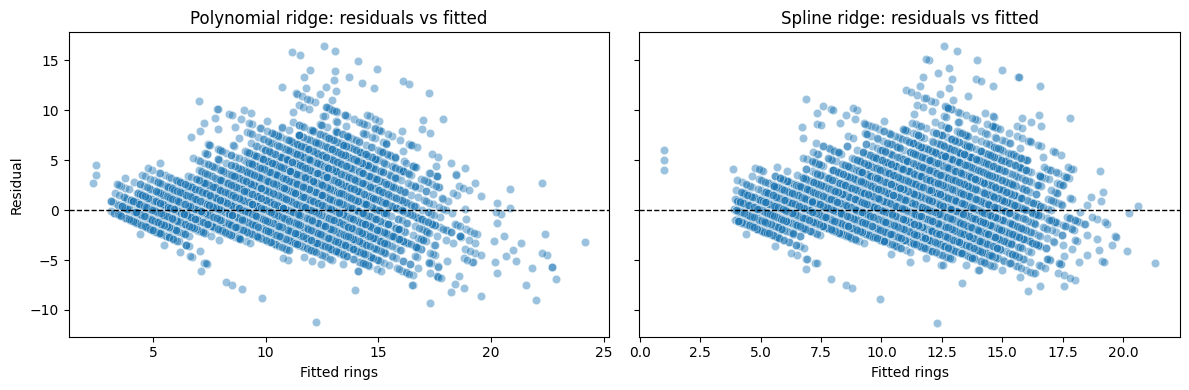

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name, pred in [
    (axes[0], "Polynomial ridge", np.maximum(poly_valid_pred, 1)),
    (axes[1], "Spline ridge", np.maximum(spline_valid_pred, 1)),
]:
    residuals = y_valid - pred
    sns.scatterplot(x=pred, y=residuals, alpha=.45, ax=ax)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{name}: residuals vs fitted")
    ax.set_xlabel("Fitted rings")
    ax.set_ylabel("Residual")
plt.tight_layout()

The residual plots are the last check before the submission evidence.  They do not need to look perfectly normal, but they should not show a strong systematic miss that contradicts the model comparison.  Together, the validation table, residual summaries, range table, and plots make the Kaggle section read like a small predictive study rather than a pair of leaderboard uploads.  The evidence cell below documents the fresh submitted files and their leaderboard status.

In [20]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
expected_files = set(['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv'])
seen_files = set()
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A4_" in parts[1] and parts[1] in expected_files and parts[1] not in seen_files:
        seen_files.add(parts[1])
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A4_polynomial_ridge_chapter7_playground_series_s4e4.csv', 'A4_spline_ridge_chapter7_playground_series_s4e4.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,53577961,A4_spline_ridge_chapter7_playground_series_s4e...,2026-06-11 18:13:50.623000,A4 spline ridge alpha selected,SubmissionStatus.COMPLETE,0.15736,0.15705
1,53577958,A4_polynomial_ridge_chapter7_playground_series...,2026-06-11 18:13:41.437000,A4 polynomial ridge alpha selected,SubmissionStatus.COMPLETE,0.15647,0.15562


,submission_file,exists_locally
0,A4_polynomial_ridge_chapter7_playground_series...,True
1,A4_spline_ridge_chapter7_playground_series_s4e...,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb


## Interpretation

For Auto, the fitted plots and cross-validation tables show the same substantive pattern: mpg falls quickly as horsepower increases and then flattens among high-horsepower cars.  A straight line misses that curvature.  Polynomial regression is smooth but can wiggle at the boundaries, step functions are easy to read but impose abrupt jumps, and splines give a smoother local fit.  Missingness and physically impossible Abalone measurements were checked before modeling because nonlinear transformations can silently amplify data-quality problems if rows are dropped without explanation (Little & Rubin, 2019; Tukey, 1977).  For Abalone, the polynomial ridge and spline ridge submissions make the nonlinear basis choice explicit.  The assumption investigation focuses on validation behavior, residual structure, error by fitted range, missing-data handling, and overfitting control because these prediction models are being judged by held-out RMSLE rather than by ordinary least squares inference alone.  The biological interpretation remains limited: the models predict ring count from measurements, but they do not explain abalone age causally (Nash et al., 1994).

## References

Hastie, T., & Tibshirani, R. (1990). *Generalized additive models*.  Chapman and Hall.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Little, R.  J.  A., & Rubin, D.  B. (2019). *Statistical analysis with missing data* (3rd ed.).  Wiley. https://doi.org/10.1002/9781119482260

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.

Tukey, J.  W. (1977). *Exploratory data analysis*.  Addison-Wesley.